<a href="https://colab.research.google.com/github/kangtayie/Machine-Learning_class/blob/main/wine_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 와인 데이터로 알코올 예측 회귀

In [1]:
# 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 회귀용 모델 4개 (분류의 Classifier → Regressor, LogisticRegression → LinearRegression)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

In [2]:
# 데이터 불러오기
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/wine.csv")
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


### 회귀용 데이터 만들기(레이블 교체)

In [3]:
# Wine(분류 레이블) 제거 → Alcohol을 새 정답으로
df_reg = df.drop("Wine", axis=1)

X = df_reg.drop("Alcohol", axis=1)   # Alcohol 빼고 나머지가 입력
y = df_reg["Alcohol"]                # Alcohol이 예측 대상(연속값)

In [4]:
# 입력 데이터 확인
X

,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...
173,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [5]:
# 정답 확인
y

,Alcohol
0,14.23
1,13.20
2,13.16
3,14.37
4,13.24
...,...
173,13.71
174,13.40
175,13.27
176,13.17


### 훈련/테스트 분리

In [6]:
# 회귀는 stratify 안 씀 (y가 연속값이라 계층을 나눌 수 없음)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# 모델 생성 → 훈련 → 예측 → 평가
reg_models = {
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "Linear": LinearRegression(),
    "KNN": KNeighborsRegressor(),
}

for name, model in reg_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)          # 평균적으로 얼마나 틀렸나
    rmse = np.sqrt(mean_squared_error(y_test, pred)) # 큰 오차에 더 민감
    r2 = r2_score(y_test, pred)                      # 1에 가까울수록 좋음
    print(f"--- {name} ---")
    print(f"MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}\n")

--- DecisionTree ---
MAE=0.438  RMSE=0.559  R2=0.477

--- RandomForest ---
MAE=0.316  RMSE=0.393  R2=0.742

--- Linear ---
MAE=0.368  RMSE=0.431  R2=0.689

--- KNN ---
MAE=0.450  RMSE=0.565  R2=0.466



# 정답값(알코올) 분포 시각화

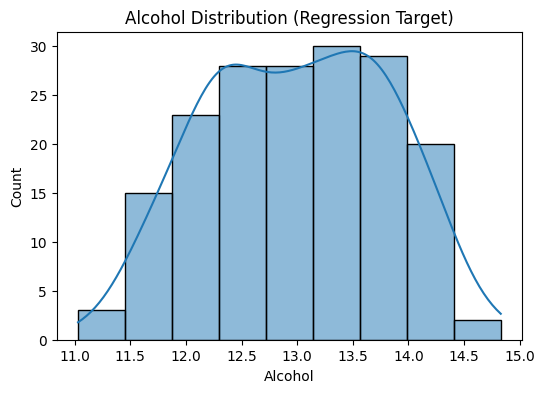

In [8]:
plt.figure(figsize=(6, 4))
sns.histplot(y, kde=True)
plt.title("Alcohol Distribution (Regression Target)")
plt.xlabel("Alcohol")
plt.ylabel("Count")
plt.show()

# 예측값 vs 실제값 시각화

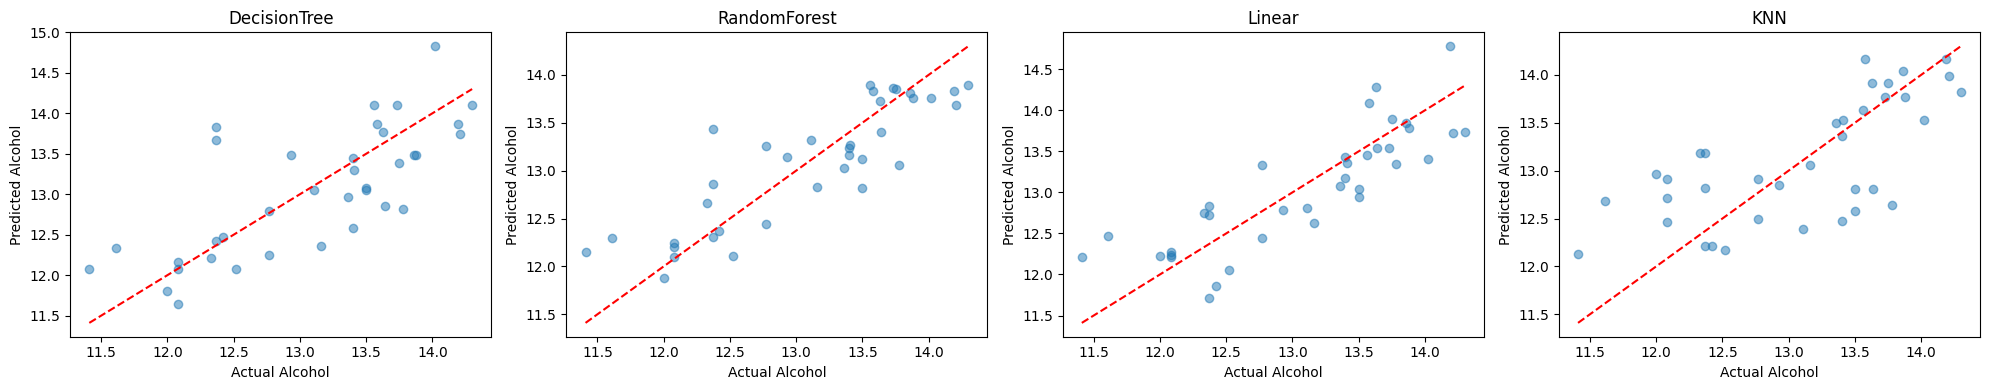

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, model) in zip(axes, reg_models.items()):
    pred = model.predict(X_test)
    ax.scatter(y_test, pred, alpha=0.5)
    lims = [y_test.min(), y_test.max()]
    ax.plot(lims, lims, "r--")   # 완벽 예측선
    ax.set_xlabel("Actual Alcohol")
    ax.set_ylabel("Predicted Alcohol")
    ax.set_title(name)
plt.tight_layout()
plt.show()